In [28]:
%pip install transformers torch scikit-learn pandas numpy tqdm


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


In [30]:
train_df = pd.read_csv('../data/processed/train.csv')
val_df   = pd.read_csv('../data/processed/val.csv')
test_df  = pd.read_csv('../data/processed/test.csv')

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'\nCategory distribution in train:')
print(train_df['category_name'].value_counts())

Train: 1540 | Val: 330 | Test: 330

Category distribution in train:
category_name
Positive Praise    580
Bug Report         524
UX Feedback        307
Feature Request    129
Name: count, dtype: int64


In [31]:
print('=== SVM Baseline — Category Classification ===')

# TF-IDF vectorisation
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])

y_train = train_df['category_label']
y_test  = test_df['category_label']

# Train SVM
# class_weight='balanced' implements the "class-weighted loss" mitigation
# decided in 02_eda.ipynb (Step 14) given the 4.5x target-class imbalance
svm_model = SVC(kernel='linear', C=1.0, random_state=42, class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)

# Evaluate
svm_preds = svm_model.predict(X_test_tfidf)
print('\nSVM Classification Report:')
print(classification_report(
    y_test, svm_preds,
    target_names=['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise']
))

svm_report = classification_report(
    y_test, svm_preds,
    target_names=['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise'],
    output_dict=True
)
svm_macro_f1 = svm_report['macro avg']['f1-score']
print(f'Overall Accuracy: {accuracy_score(y_test, svm_preds):.4f}')
print(f'Macro F1: {svm_macro_f1:.4f}')

=== SVM Baseline — Category Classification ===

SVM Classification Report:
                 precision    recall  f1-score   support

     Bug Report       0.66      0.71      0.69       112
Feature Request       0.76      0.46      0.58        28
    UX Feedback       0.58      0.64      0.60        66
Positive Praise       0.82      0.79      0.81       124

       accuracy                           0.71       330
      macro avg       0.71      0.65      0.67       330
   weighted avg       0.71      0.71      0.71       330

Overall Accuracy: 0.7061
Macro F1: 0.6688


In [32]:
# Load BERT tokeniser
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN = 128
BATCH_SIZE = 16

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts    = texts
        self.labels   = labels
        self.tokenizer = tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

print('Dataset class defined')

Dataset class defined


In [33]:
def train_bert(train_df, val_df, label_col, num_labels, model_name):
    """
    Fine-tune BERT for sequence classification.
    label_col: column name for labels (category_label or sentiment_label)
    num_labels: number of output classes
    model_name: name for saving the model
    """
    # Create datasets
    train_dataset = ReviewDataset(
        train_df['clean_text'].tolist(),
        train_df[label_col].tolist(),
        tokenizer, MAX_LEN
    )
    val_dataset = ReviewDataset(
        val_df['clean_text'].tolist(),
        val_df[label_col].tolist(),
        tokenizer, MAX_LEN
    )
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

    # Load model
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=num_labels
    ).to(device)

    
    class_weights = compute_class_weight(
        'balanced',
        classes=np.arange(num_labels),
        y=train_df[label_col].values
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    print(f'Class weights ({label_col}): {class_weights.cpu().numpy().round(3)}')

    # Optimiser and scheduler
    EPOCHS = 3
    optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        # --- TRAINING ---
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]'):
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            loss = loss_fn(outputs.logits, batch['label'].to(device))
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]'):
                outputs = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device)
                )
                val_loss = loss_fn(outputs.logits, batch['label'].to(device))
                total_val_loss += val_loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f} | Val Loss={avg_val_loss:.4f}')

    # Save model
    os.makedirs(f'../models/{model_name}', exist_ok=True)
    model.save_pretrained(f'../models/{model_name}')
    tokenizer.save_pretrained(f'../models/{model_name}')
    print(f'\nModel saved to ../models/{model_name}')

    return model, train_losses, val_losses

print('Training function defined')

Training function defined


In [34]:
print('Training BERT for CATEGORY classification...')
category_model, cat_train_losses, cat_val_losses = train_bert(
    train_df, val_df,
    label_col='category_label',
    num_labels=4,
    model_name='bert_category'
)

Training BERT for CATEGORY classification...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9842.77it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Class weights (category_label): [0.735 2.984 1.254 0.664]


Epoch 1/3 [Val]: 100%|██████████| 21/21 [00:08<00:00,  2.40it/s]


Epoch 1: Train Loss=1.2044 | Val Loss=1.0655


...

Epoch 2: Train Loss=0.9867 | Val Loss=0.9544


Epoch 3/3 [Val]: 100%|██████████| 21/21 [00:08<00:00,  2.56it/s]


Epoch 3: Train Loss=0.8200 | Val Loss=0.9451


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.70it/s]


Model saved to ../models/bert_category


In [36]:
print('Training BERT for SENTIMENT classification...')
sentiment_model, sent_train_losses, sent_val_losses = train_bert(
    train_df, val_df,
    label_col='sentiment_label',
    num_labels=3,
    model_name='bert_sentiment'
)

Training BERT for SENTIMENT classification...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 22631.34it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

Class weights (sentiment_label): [0.699 4.709 0.736]


Epoch 1/3 [Val]: 100%|██████████| 21/21 [00:07<00:00,  2.87it/s]


Epoch 1: Train Loss=0.9852 | Val Loss=0.7589


...

Epoch 2: Train Loss=0.6822 | Val Loss=0.7724


Epoch 3/3 [Val]: 100%|██████████| 21/21 [00:07<00:00,  2.76it/s]


Epoch 3: Train Loss=0.5168 | Val Loss=0.7553


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.34it/s]


Model saved to ../models/bert_sentiment


In [37]:
def evaluate_bert(model, test_df, label_col, label_names):
    test_dataset = ReviewDataset(
        test_df['clean_text'].tolist(),
        test_df[label_col].tolist(),
        tokenizer, MAX_LEN
    )
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Evaluating'):
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())

    report = classification_report(all_labels, all_preds, target_names=label_names, output_dict=True)
    macro_f1 = report['macro avg']['f1-score']

    print(classification_report(all_labels, all_preds, target_names=label_names))
    print(f'Accuracy: {accuracy_score(all_labels, all_preds):.4f}')
    print(f'Macro F1: {macro_f1:.4f}')
    return all_preds, all_labels, macro_f1

print('=== BERT — Category Classification ===')
cat_preds, cat_labels, cat_macro_f1 = evaluate_bert(
    category_model, test_df, 'category_label',
    ['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise']
)

print('\n=== BERT — Sentiment Classification ===')
sent_preds, sent_labels, sent_macro_f1 = evaluate_bert(
    sentiment_model, test_df, 'sentiment_label',
    ['Negative', 'Neutral', 'Positive']
)

=== BERT — Category Classification ===


Evaluating: 100%|██████████| 21/21 [00:06<00:00,  3.04it/s]


                 precision    recall  f1-score   support

     Bug Report       0.75      0.53      0.62       112
Feature Request       0.26      0.29      0.27        28
    UX Feedback       0.48      0.73      0.58        66
Positive Praise       0.86      0.83      0.84       124

       accuracy                           0.66       330
      macro avg       0.59      0.59      0.58       330
   weighted avg       0.69      0.66      0.67       330

Accuracy: 0.6606
Macro F1: 0.5779

=== BERT — Sentiment Classification ===


Evaluating: 100%|██████████| 21/21 [00:07<00:00,  2.91it/s]

              precision    recall  f1-score   support

    Negative       0.81      0.86      0.83       153
     Neutral       0.24      0.22      0.23        32
    Positive       0.87      0.83      0.85       145

    accuracy                           0.78       330
   macro avg       0.64      0.64      0.64       330
weighted avg       0.78      0.78      0.78       330

Accuracy: 0.7848
Macro F1: 0.6378


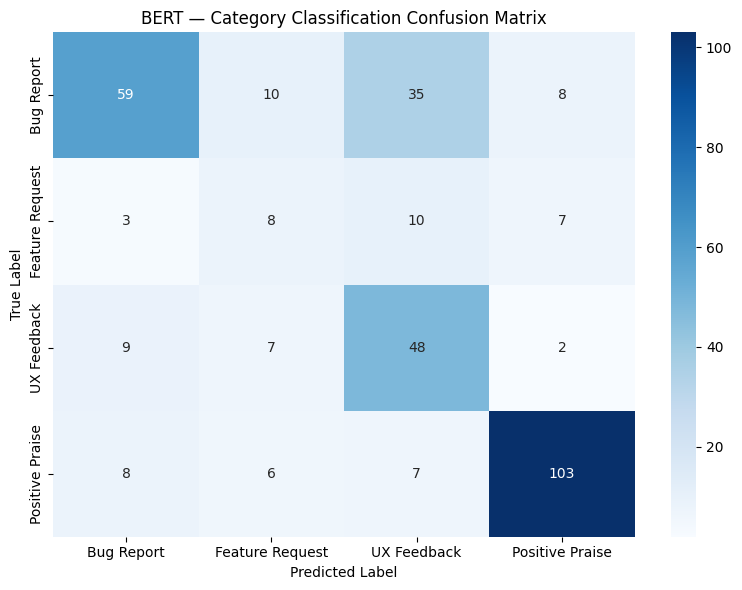

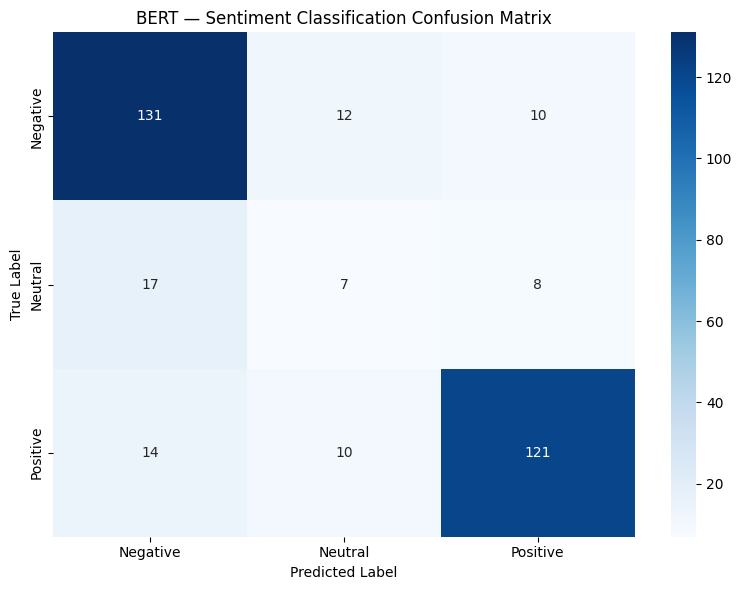

In [38]:
def plot_confusion_matrix(labels, preds, class_names, title, filename):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'../reports/{filename}', dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(
    cat_labels, cat_preds,
    ['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise'],
    'BERT — Category Classification Confusion Matrix',
    'cm_bert_category.png'
)

plot_confusion_matrix(
    sent_labels, sent_preds,
    ['Negative', 'Neutral', 'Positive'],
    'BERT — Sentiment Classification Confusion Matrix',
    'cm_bert_sentiment.png'
)

In [40]:
import json
os.makedirs('../reports', exist_ok=True)
baseline_results = {
    'svm_accuracy': accuracy_score(y_test, svm_preds),
    'svm_macro_f1': svm_macro_f1,
    'bert_category_accuracy': accuracy_score(cat_labels, cat_preds),
    'bert_category_macro_f1': cat_macro_f1,
    'bert_sentiment_accuracy': accuracy_score(sent_labels, sent_preds),
    'bert_sentiment_macro_f1': sent_macro_f1
}
with open('../reports/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)
print('Saved baseline results:', baseline_results)

# Check against proposal success criterion (Methodology 3.1): BERT macro F1 >= 0.75
if cat_macro_f1 >= 0.75:
    print(f'\nSuccess criterion MET: BERT category macro F1 = {cat_macro_f1:.4f} >= 0.75')
else:
    print(f'\nSuccess criterion NOT met: BERT category macro F1 = {cat_macro_f1:.4f} < 0.75')

Saved baseline results: {'svm_accuracy': 0.706060606060606, 'svm_macro_f1': 0.6688434914125606, 'bert_category_accuracy': 0.6606060606060606, 'bert_category_macro_f1': 0.5778907589731002, 'bert_sentiment_accuracy': 0.7848484848484848, 'bert_sentiment_macro_f1': 0.6377889681745604}

Success criterion NOT met: BERT category macro F1 = 0.5779 < 0.75
